<a href="https://colab.research.google.com/github/MALIBALAJI95/GEN-AI/blob/main/Gen_PE_lab2(PCA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.9 MB/s eta 0:00:00


In [ ]:
"""
Lab Activity: Exploring Pre-trained Word Vectors (GloVe version)
------------------------------------------------------------------
This version uses a SMALLER, easy-to-download pre-trained embedding
set instead of the large (~3.6 GB) GoogleNews-vectors-negative300.bin
file. It uses gensim's built-in downloader to fetch GloVe vectors
trained on Wikipedia + Gigaword (100-dimensional), which downloads
automatically the first time you run it (~66 MB) — no manual file
path needed.

Steps demonstrated:
1. Load pre-trained word vectors (GloVe, 100-dim)
2. Select domain-specific words (Technology domain)
3. Extract their vector representations
4. Reduce dimensionality with PCA for visualization
5. Plot and analyze clusters/relationships
6. Find semantically similar words for a given word
"""

# -------------------------------------------------------------
# STEP 1: Load Pre-trained Word Vectors (GloVe via gensim downloader)
# -------------------------------------------------------------
import gensim.downloader as api

# This automatically downloads (once, then caches locally) and loads
# 100-dimensional GloVe vectors trained on Wikipedia + Gigaword.
# Other options you could swap in: 'glove-wiki-gigaword-50',
# 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'word2vec-google-news-300'
print("Downloading/loading GloVe word vectors (first run may take a minute)...")
word_vectors = api.load('glove-wiki-gigaword-100')

print("Word vectors loaded successfully!\n")









Downloading/loading GloVe word vectors (first run may take a minute)...
[==================================================] 100.0% 128.1/128.1MB downloaded
Word vectors loaded successfully!



In [ ]:
# -------------------------------------------------------------
# STEP 2: Select 10 Words from a Specific Domain (Technology)
# -------------------------------------------------------------
words = [
    'computer', 'software', 'hardware', 'algorithm', 'data',
    'network', 'internet', 'programming', 'database', 'cloud'
]


In [ ]:
# -------------------------------------------------------------
# STEP 3: Extract Word Vectors
# -------------------------------------------------------------
import numpy as np

# Build a NumPy array where each row is the 100-dim vector for a word.
vectors = np.array([word_vectors[word] for word in words])

print(f"Extracted vectors shape: {vectors.shape}")  # Expected: (10, 100)

Extracted vectors shape: (10, 100)


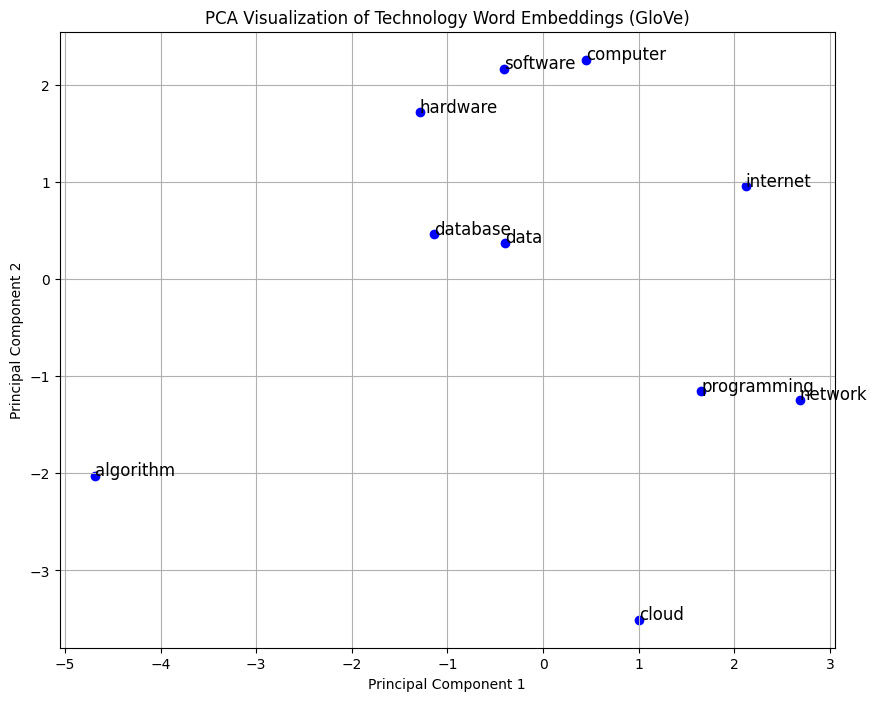

In [ ]:
# -------------------------------------------------------------
# STEP 4: Apply Dimensionality Reduction (PCA)
# -------------------------------------------------------------
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce the 100-dimensional vectors down to 2 dimensions so we
# can visualize them on a 2D scatter plot.
pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

# Create the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], color='blue')

# Annotate each point with its corresponding word
for i, word in enumerate(words):
    plt.annotate(
        word,
        xy=(vectors_2d[i, 0], vectors_2d[i, 1]),
        fontsize=12
    )

plt.title('PCA Visualization of Technology Word Embeddings (GloVe)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

In [ ]:
# -------------------------------------------------------------
# STEP 5: Analyze Clusters and Relationships
# -------------------------------------------------------------
# After plotting, visually inspect which words appear close together.
# Words like "computer", "hardware", and "software" are expected to
# cluster together since they are semantically related within the
# technology domain (they frequently co-occur in similar contexts).
# Words like "cloud" or "internet" may form a slightly different
# sub-cluster related to networking/connectivity concepts.

print("\nCheck the PCA plot: words that are semantically related "
      "(e.g., 'computer', 'hardware', 'software') should appear "
      "closer together in the 2D space.\n")



Check the PCA plot: words that are semantically related (e.g., 'computer', 'hardware', 'software') should appear closer together in the 2D space.



In [ ]:
# -------------------------------------------------------------
# STEP 6: Generate Semantically Similar Words
# -------------------------------------------------------------
def find_similar_words(word, topn=5):
    """
    Find and print the top-N most semantically similar words
    to the given input word, using cosine similarity between
    word vectors.

    Parameters:
        word (str): The target word to find similar words for.
        topn (int): Number of similar words to return (default 5).
    """
    try:
        similar_words = word_vectors.most_similar(word, topn=topn)
        print(f"Words similar to '{word}':")
        for similar_word, similarity in similar_words:
            print(f"  {similar_word}: {similarity:.2f}")
    except KeyError:
        # Raised if the word is not present in the model's vocabulary
        print(f"'{word}' is not in the vocabulary.")



In [ ]:
# -------------------------------------------------------------
# STEP 7: Test the function on a few sample words
# -------------------------------------------------------------
if __name__ == "__main__":
    for test_word in ['computer', 'algorithm', 'cloud']:
        find_similar_words(test_word, topn=5)
        print()  # blank line for readability

Words similar to 'computer':
  computers: 0.88
  software: 0.84
  technology: 0.76
  pc: 0.74
  hardware: 0.73

Words similar to 'algorithm':
  algorithms: 0.85
  optimization: 0.72
  approximation: 0.70
  iterative: 0.67
  computation: 0.66

Words similar to 'cloud':
  clouds: 0.77
  ash: 0.71
  dust: 0.66
  sky: 0.62
  mist: 0.61

